In [1]:
import sqlite3

In [2]:
#create/connect the database
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

In [3]:
# Creating table
cursor.execute("""
CREATE TABLE IF NOT EXISTS sales (
    product TEXT,
    quantity INTEGER,
    price REAL
)
""")

# inserting data
sales_data = [
    ('Laptop', 5, 50000),
    ('Mobile', 10, 15000),
    ('Tablet', 7, 20000),
    ('Laptop', 3, 52000),
    ('Mobile', 6, 14000),
    ('Tablet', 4, 21000)
]
cursor.executemany("INSERT INTO sales VALUES (?, ?, ?)", sales_data)

In [4]:
conn.commit()
conn.close()

print("Database and table created with sample data!")

Database and table created with sample data!


In [5]:
import pandas as pd

# Connect to the database
conn = sqlite3.connect("sales_data.db")

# Write SQL query
query = "SELECT * FROM sales"

# Use Pandas to read the table into a DataFrame
df = pd.read_sql_query(query, conn)

# Display the DataFrame
print(df)

# Close connection
conn.close()


   product  quantity    price
0   Laptop         5  50000.0
1   Mobile        10  15000.0
2   Tablet         7  20000.0
3   Laptop         3  52000.0
4   Mobile         6  14000.0
5   Tablet         4  21000.0
6   Laptop         5  50000.0
7   Mobile        10  15000.0
8   Tablet         7  20000.0
9   Laptop         3  52000.0
10  Mobile         6  14000.0
11  Tablet         4  21000.0


In [6]:
import sqlite3
import pandas as pd

# Connect to the database
conn = sqlite3.connect("sales_data.db")

# SQL query to calculate total quantity and revenue for each product
query = """
SELECT 
    product,
    SUM(quantity) AS total_quantity,
    SUM(quantity * price) AS total_revenue
FROM sales
GROUP BY product
"""

# Run query and store in DataFrame
df = pd.read_sql_query(query, conn)

# Display results
print(df)

# Close connection
conn.close()


  product  total_quantity  total_revenue
0  Laptop              16       812000.0
1  Mobile              32       468000.0
2  Tablet              22       448000.0


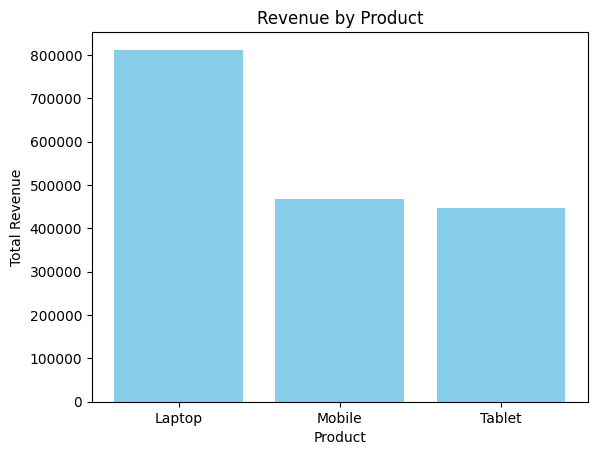

In [7]:
import matplotlib.pyplot as plt


# Plot Revenue
plt.bar(df['product'], df['total_revenue'], color='skyblue')
plt.xlabel("Product")
plt.ylabel("Total Revenue")
plt.title("Revenue by Product")
plt.show()


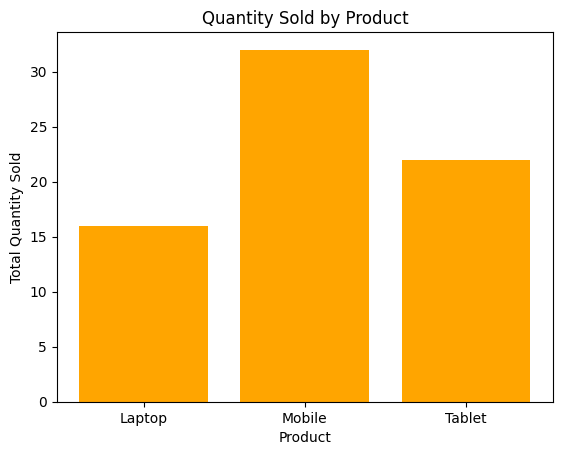

In [8]:
plt.bar(df['product'], df['total_quantity'], color='orange')
plt.xlabel("Product")
plt.ylabel("Total Quantity Sold")
plt.title("Quantity Sold by Product")
plt.show()
